In [ ]:
import pandas as pd

df = pd.read_csv("combined_results.csv")


,model_path,folder,val_loss,val_acc,time_per_image,throughput,nums_trainable_parameters
0,model_weights/final_checkpoint_resnet18_batch_...,masked,1.370018,0.635802,0.000070,14233.909027,51813
1,model_weights/final_checkpoint_resnet18_batch_...,clean,1.191958,0.678733,0.000051,19683.366444,51813
2,model_weights/final_checkpoint_resnet18_batch_...,downsampled,3.599344,0.229465,0.000049,20258.121235,51813
3,model_weights/final_checkpoint_resnet18_batch_...,blur_medium,2.459206,0.397307,0.000052,19417.276592,51813
4,model_weights/final_checkpoint_resnet18_batch_...,blur_little,1.525196,0.595842,0.000051,19674.948674,51813


In [38]:
# num of trained parameters vs improvement over baseline

df_grouped = df.groupby("model_path").agg({
    "val_loss": "mean",
    "val_acc": "mean",
    "throughput": "mean",
    "nums_trainable_parameters": "mean"
}).reset_index()

df_over_baseline = df_grouped.copy()
baseline_acc_res = df_grouped[df_grouped["model_path"].str.contains("resnet18_linear_probe")]["val_acc"]
baseline_acc_eff = df_grouped[df_grouped["model_path"].str.contains("efficientnet_linear_probe")]["val_acc"]



resnet_df = df_over_baseline[df_over_baseline["model_path"].str.contains("resnet")]
resnet_df["acc_over_baseline"] = resnet_df["val_acc"] - baseline_acc_res.values[0]
efficientnet_df = df_over_baseline[df_over_baseline["model_path"].str.contains("efficientnet")]
efficientnet_df["acc_over_baseline"] = efficientnet_df["val_acc"] - baseline_acc_eff.values[0]

In [39]:
resnet_df

,model_path,val_loss,val_acc,throughput,nums_trainable_parameters,acc_over_baseline
4,model_weights/final_checkpoint_resnet18_batch_...,1.948420,0.520950,18913.692941,51813.0,0.094026
5,model_weights/final_checkpoint_resnet18_custom...,1.688231,0.571465,9786.243891,194469.0,0.144541
6,model_weights/final_checkpoint_resnet18_linear...,2.413330,0.426924,19428.036002,51813.0,0.000000
7,model_weights/final_checkpoint_resnet18_lora.pt,2.040917,0.513630,18576.245452,572517.0,0.086706
8,model_weights/final_checkpoint_resnet18_task_s...,1.960891,0.521809,16555.919997,139933.0,0.094884


In [40]:

import altair as alt

res_chart = alt.Chart(resnet_df).mark_point().encode(
    x="nums_trainable_parameters",
    y="acc_over_baseline",
    color="model_path"
)

efficientnet_chart = alt.Chart(efficientnet_df).mark_point().encode(
    x="nums_trainable_parameters",
    y="acc_over_baseline",
    color="model_path"
)

res_chart | efficientnet_chart

alt.HConcatChart(...)

analysis to be done
- Compare acc across all models
- Compare between EfficientNet and ResNet models
- Between different test sets
- Compare numbers of parameters vs accuracy over baseline (linear_probe) for all models
- Compare inference time per image for all models
- Visualizations showing trade-offs between performance and model efficiency, such as bubble plots of performance vs FLOPs2
or wall-clock time, with bubble  size proportional to trainable parameter count. 
- Similar plots should be created for inference speed vs performance.

Make nice charts out of these.
Make grad cam files




## Added analysis
The cells below complete the comparison and visualization section using `combined_results.csv`. 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

analysis_df = pd.read_csv("combined_results.csv").copy()

def get_backbone(model_path):
    if "efficientnet" in model_path.lower():
        return "EfficientNetV2-S"
    if "resnet" in model_path.lower():
        return "ResNet18"
    return "Other"

def get_method(model_path):
    model_path = model_path.lower()
    if "linear_probe" in model_path:
        return "Linear Probe"
    if "batch_norm" in model_path:
        return "BatchNorm Tuning"
    if "task_specific_adapter" in model_path or "task_specific_adapters" in model_path:
        return "Task-Specific Adapter"
    if "lora" in model_path:
        return "LoRA"
    if "custom_model" in model_path:
        return "Custom Model"
    return "Other"

analysis_df["backbone"] = analysis_df["model_path"].apply(get_backbone)
analysis_df["method"] = analysis_df["model_path"].apply(get_method)
analysis_df["model_name"] = analysis_df["backbone"] + " | " + analysis_df["method"]

test_set_order = ["clean", "masked", "noise_rotation", "blur_little", "blur_medium", "downsampled"]
analysis_df["folder"] = pd.Categorical(analysis_df["folder"], categories=test_set_order, ordered=True)

model_summary = (
    analysis_df.groupby(["model_path", "backbone", "method", "model_name"], as_index=False)
    .agg(
        mean_accuracy=("val_acc", "mean"),
        mean_loss=("val_loss", "mean"),
        clean_accuracy=("val_acc", lambda s: s[analysis_df.loc[s.index, "folder"] == "clean"].iloc[0]),
        avg_time_per_image=("time_per_image", "mean"),
        avg_throughput=("throughput", "mean"),
        trainable_parameters=("nums_trainable_parameters", "mean")
    )
)

baseline_map = (
    model_summary[model_summary["method"] == "Linear Probe"]
    .set_index("backbone")["mean_accuracy"]
    .to_dict()
)
model_summary["accuracy_over_baseline"] = model_summary.apply(
    lambda row: row["mean_accuracy"] - baseline_map[row["backbone"]], axis=1
)
model_summary["params_millions"] = model_summary["trainable_parameters"] / 1_000_000
model_summary["images_per_second"] = 1.0 / model_summary["avg_time_per_image"]

display_cols = [
    "backbone", "method", "clean_accuracy", "mean_accuracy", "accuracy_over_baseline",
    "avg_time_per_image", "avg_throughput", "trainable_parameters"
]
model_summary = model_summary.sort_values(["mean_accuracy", "clean_accuracy"], ascending=False).reset_index(drop=True)
model_summary[display_cols]


,backbone,method,clean_accuracy,mean_accuracy,accuracy_over_baseline,avg_time_per_image,avg_throughput,trainable_parameters
0,EfficientNetV2-S,BatchNorm Tuning,0.864673,0.709531,0.267987,0.002878,347.640551,283253.0
1,EfficientNetV2-S,LoRA,0.849426,0.667729,0.226185,0.002120,471.675004,1511997.0
2,EfficientNetV2-S,Task-Specific Adapter,0.806455,0.630442,0.188898,0.002805,356.568597,153729.0
3,ResNet18,Custom Model,0.695604,0.571465,0.144541,0.000102,9786.243891,194469.0
4,ResNet18,Task-Specific Adapter,0.673703,0.521809,0.094884,0.000060,16555.919997,139933.0
5,ResNet18,BatchNorm Tuning,0.678733,0.520950,0.094026,0.000054,18913.692941,51813.0
6,ResNet18,LoRA,0.673782,0.513630,0.086706,0.000054,18576.245452,572517.0
7,EfficientNetV2-S,Linear Probe,0.617703,0.441545,0.000000,0.002786,358.915069,129381.0
8,ResNet18,Linear Probe,0.575762,0.426924,0.000000,0.000051,19428.036002,51813.0


In [3]:
summary_report = model_summary[[
    "backbone", "method", "clean_accuracy", "mean_accuracy", "accuracy_over_baseline",
    "avg_time_per_image", "avg_throughput", "trainable_parameters"
]].copy()
summary_report["clean_accuracy"] = summary_report["clean_accuracy"].map(lambda x: f"{x:.3f}")
summary_report["mean_accuracy"] = summary_report["mean_accuracy"].map(lambda x: f"{x:.3f}")
summary_report["accuracy_over_baseline"] = summary_report["accuracy_over_baseline"].map(lambda x: f"{x:+.3f}")
summary_report["avg_time_per_image"] = summary_report["avg_time_per_image"].map(lambda x: f"{x * 1000:.3f} ms")
summary_report["avg_throughput"] = summary_report["avg_throughput"].map(lambda x: f"{x:,.1f}")
summary_report["trainable_parameters"] = summary_report["trainable_parameters"].map(lambda x: f"{int(x):,}")
print("Top model by mean accuracy:", model_summary.loc[0, "model_name"], f"({model_summary.loc[0, 'mean_accuracy']:.3f})")
print("Top model on the clean test set:", model_summary.sort_values('clean_accuracy', ascending=False).iloc[0]['model_name'])
print("Fastest average inference:", model_summary.sort_values('avg_time_per_image').iloc[0]['model_name'])
summary_report


Top model by mean accuracy: EfficientNetV2-S | BatchNorm Tuning (0.710)
Top model on the clean test set: EfficientNetV2-S | BatchNorm Tuning
Fastest average inference: ResNet18 | Linear Probe


,backbone,method,clean_accuracy,mean_accuracy,accuracy_over_baseline,avg_time_per_image,avg_throughput,trainable_parameters
0,EfficientNetV2-S,BatchNorm Tuning,0.865,0.710,+0.268,2.878 ms,347.6,"283,253"
1,EfficientNetV2-S,LoRA,0.849,0.668,+0.226,2.120 ms,471.7,"1,511,997"
2,EfficientNetV2-S,Task-Specific Adapter,0.806,0.630,+0.189,2.805 ms,356.6,"153,729"
3,ResNet18,Custom Model,0.696,0.571,+0.145,0.102 ms,"9,786.2","194,469"
4,ResNet18,Task-Specific Adapter,0.674,0.522,+0.095,0.060 ms,"16,555.9","139,933"
5,ResNet18,BatchNorm Tuning,0.679,0.521,+0.094,0.054 ms,"18,913.7","51,813"
6,ResNet18,LoRA,0.674,0.514,+0.087,0.054 ms,"18,576.2","572,517"
7,EfficientNetV2-S,Linear Probe,0.618,0.442,+0.000,2.786 ms,358.9,"129,381"
8,ResNet18,Linear Probe,0.576,0.427,+0.000,0.051 ms,"19,428.0","51,813"


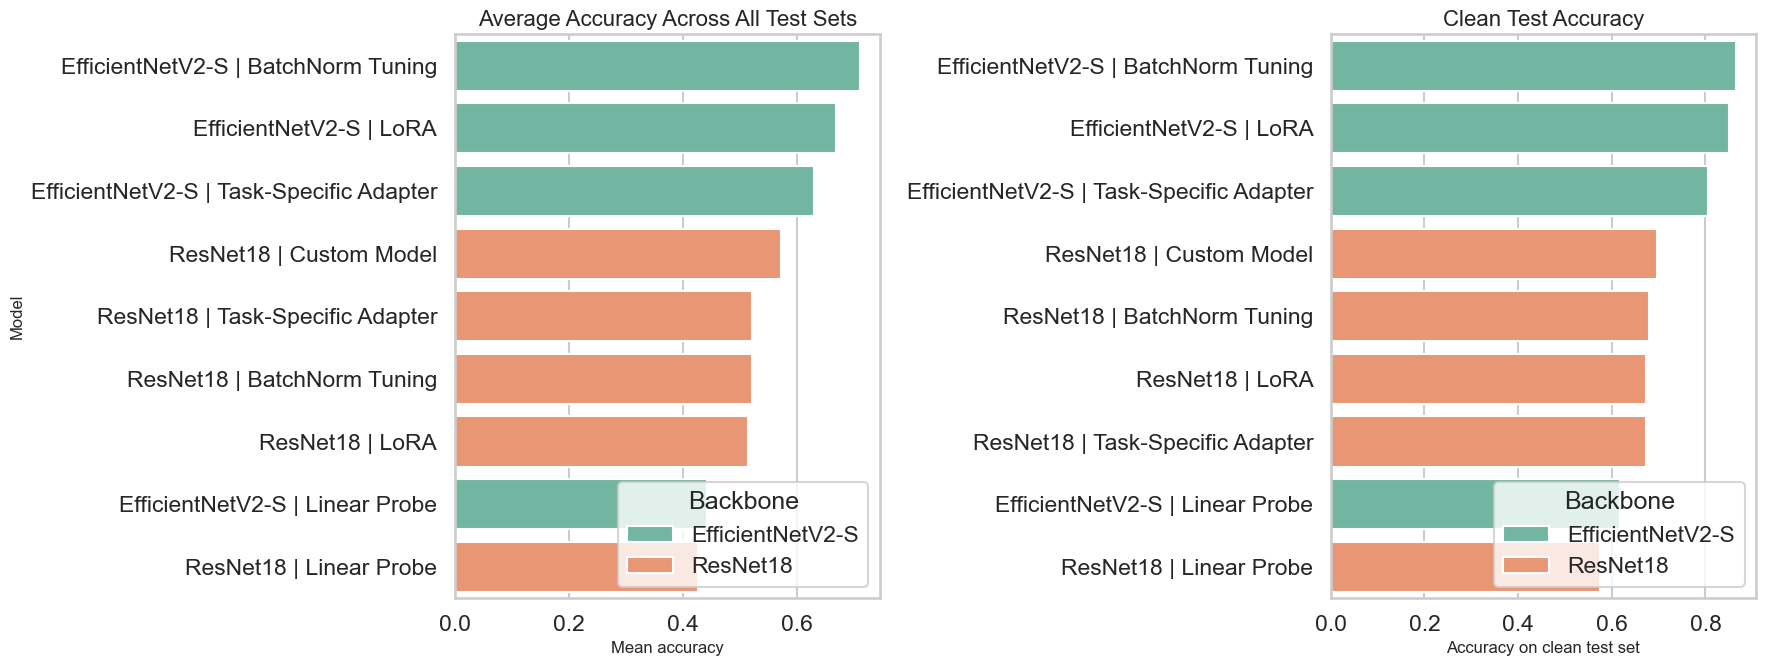

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
model_order = model_summary.sort_values("mean_accuracy", ascending=False)["model_name"]

sns.barplot(data=model_summary, x="mean_accuracy", y="model_name", hue="backbone", order=model_order, ax=axes[0], palette="Set2")
axes[0].set_title("Average Accuracy Across All Test Sets")
axes[0].set_xlabel("Mean accuracy")
axes[0].set_ylabel("Model")
axes[0].legend(title="Backbone", loc="lower right")

clean_rank = model_summary.sort_values("clean_accuracy", ascending=False)["model_name"]
sns.barplot(data=model_summary, x="clean_accuracy", y="model_name", hue="backbone", order=clean_rank, ax=axes[1], palette="Set2")
axes[1].set_title("Clean Test Accuracy")
axes[1].set_xlabel("Accuracy on clean test set")
axes[1].set_ylabel("")
axes[1].legend(title="Backbone", loc="lower right")

plt.tight_layout()
plt.show()


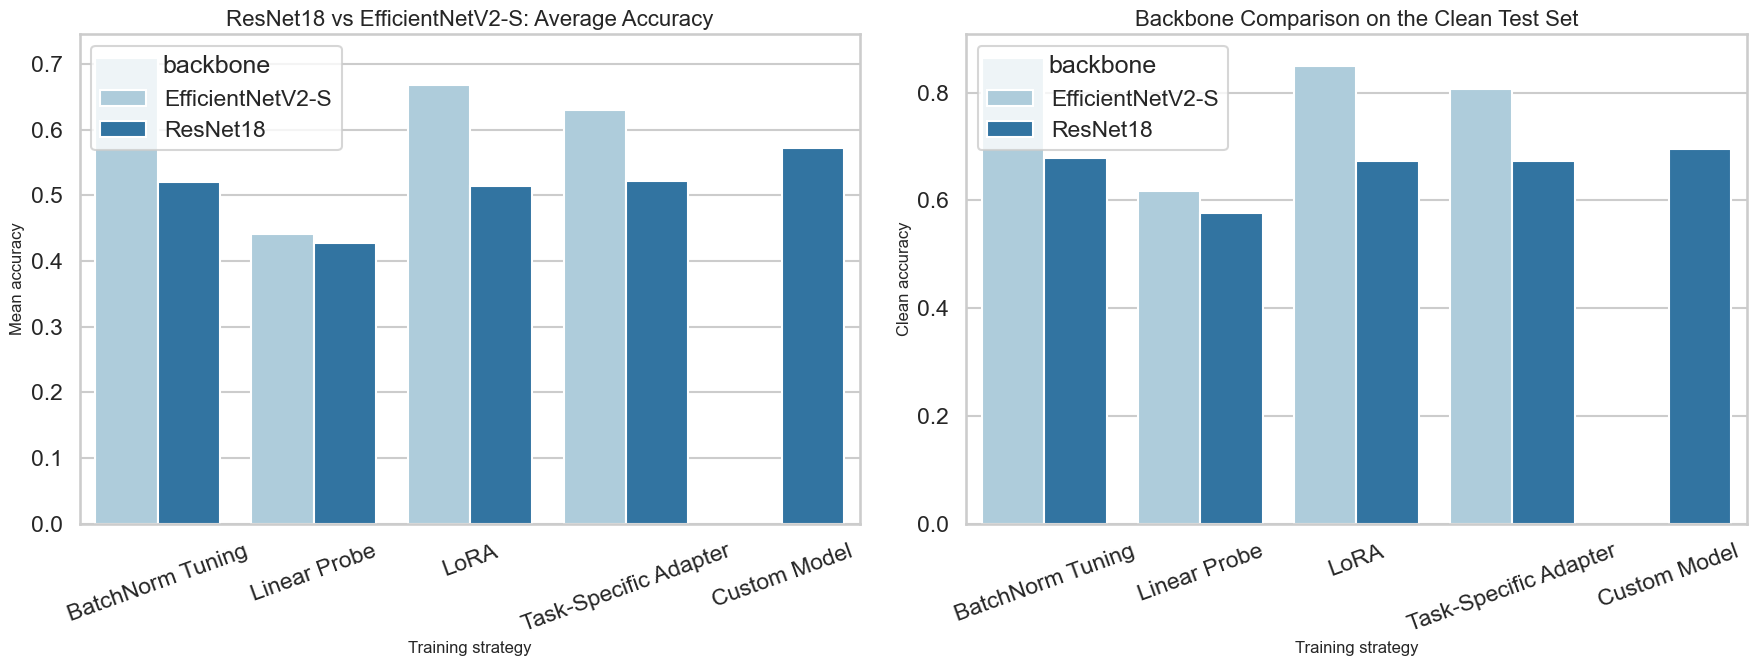

In [5]:
backbone_method_summary = (
    analysis_df.groupby(["backbone", "method"], as_index=False)
    .agg(mean_accuracy=("val_acc", "mean"), clean_accuracy=("val_acc", lambda s: s[analysis_df.loc[s.index, "folder"] == "clean"].iloc[0]))
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=backbone_method_summary, x="method", y="mean_accuracy", hue="backbone", ax=axes[0], palette="Paired")
axes[0].set_title("ResNet18 vs EfficientNetV2-S: Average Accuracy")
axes[0].set_xlabel("Training strategy")
axes[0].set_ylabel("Mean accuracy")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=backbone_method_summary, x="method", y="clean_accuracy", hue="backbone", ax=axes[1], palette="Paired")
axes[1].set_title("Backbone Comparison on the Clean Test Set")
axes[1].set_xlabel("Training strategy")
axes[1].set_ylabel("Clean accuracy")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


C:\Users\inaar\AppData\Local\Temp\ipykernel_9068\1301108120.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_set_summary, x="mean_accuracy", y="folder", ax=axes[0], palette="crest")


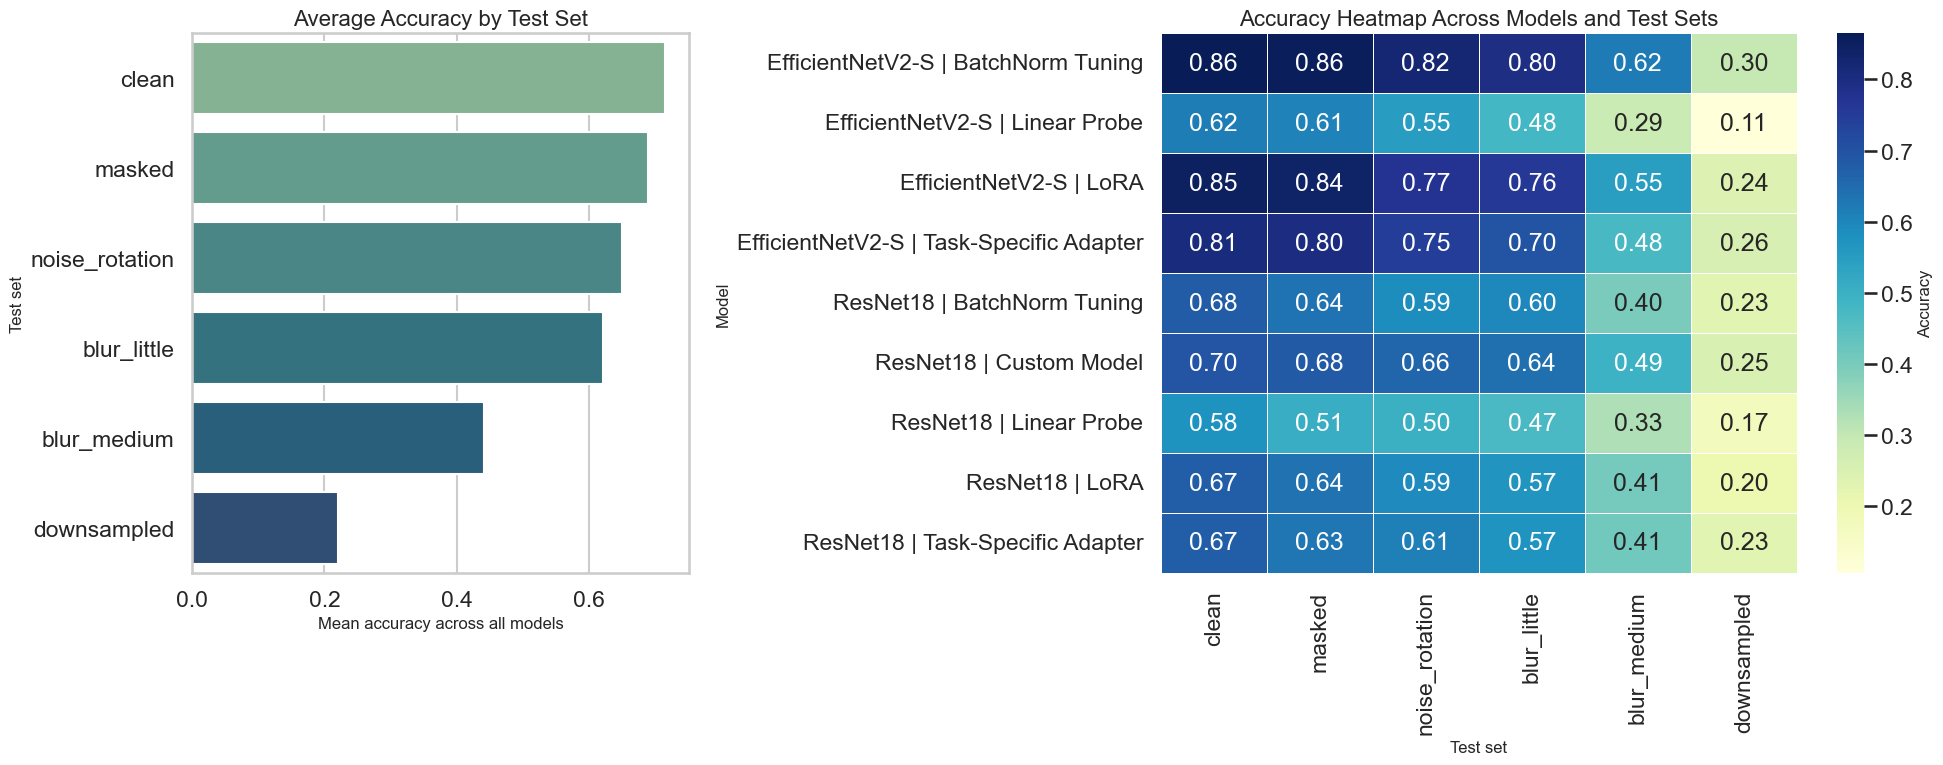

In [6]:
test_set_summary = (
    analysis_df.groupby("folder", as_index=False)
    .agg(mean_accuracy=("val_acc", "mean"), mean_loss=("val_loss", "mean"))
    .sort_values("mean_accuracy", ascending=False)
)

pivot_acc = analysis_df.pivot_table(index="model_name", columns="folder", values="val_acc")
pivot_acc = pivot_acc[test_set_order]

fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={"width_ratios": [1, 1.6]})
sns.barplot(data=test_set_summary, x="mean_accuracy", y="folder", ax=axes[0], palette="crest")
axes[0].set_title("Average Accuracy by Test Set")
axes[0].set_xlabel("Mean accuracy across all models")
axes[0].set_ylabel("Test set")

sns.heatmap(pivot_acc, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, ax=axes[1], cbar_kws={"label": "Accuracy"})
axes[1].set_title("Accuracy Heatmap Across Models and Test Sets")
axes[1].set_xlabel("Test set")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()


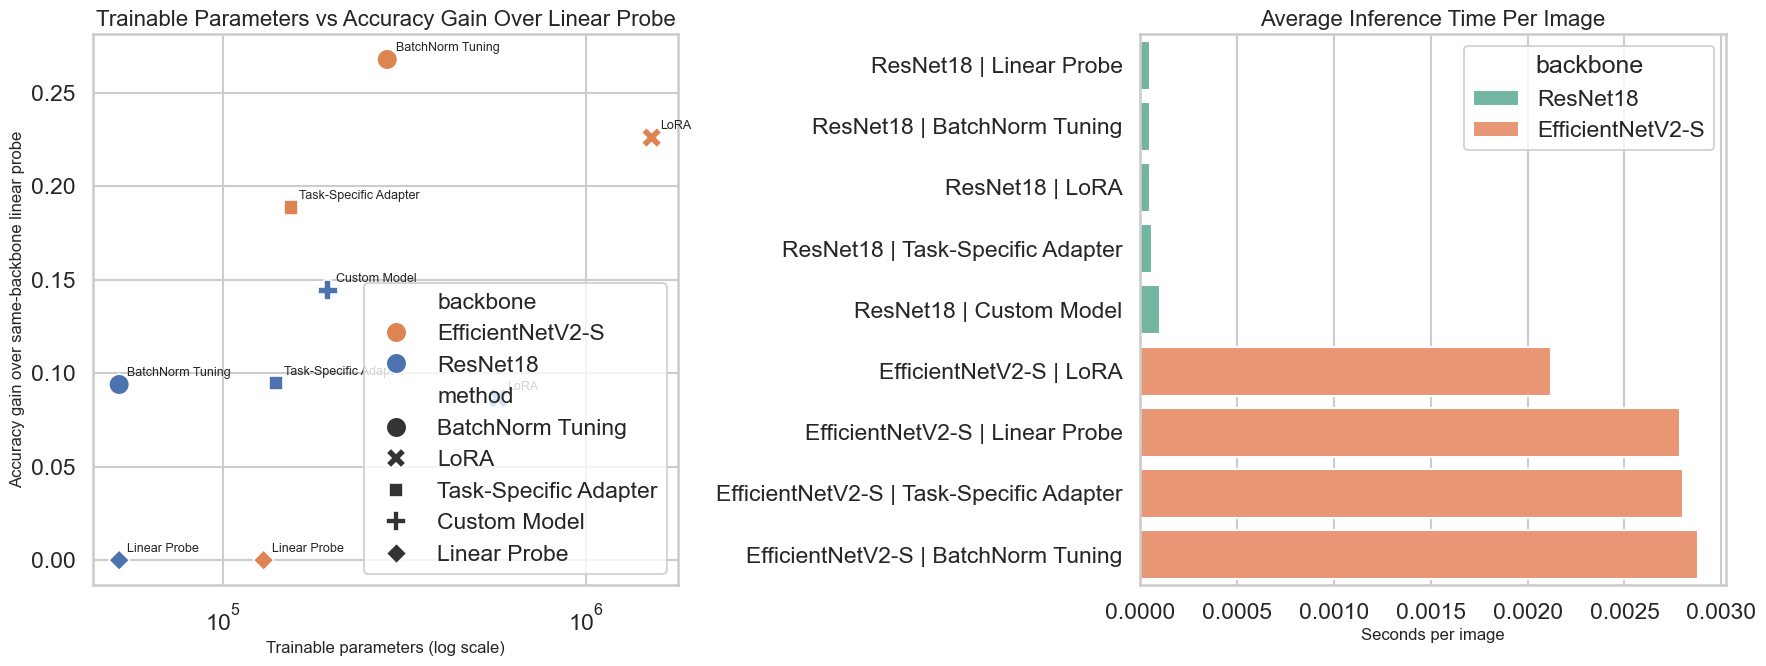

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
palette = {"ResNet18": "#4C72B0", "EfficientNetV2-S": "#DD8452"}

sns.scatterplot(
    data=model_summary, x="trainable_parameters", y="accuracy_over_baseline",
    hue="backbone", style="method", s=220, palette=palette, ax=axes[0]
)
for _, row in model_summary.iterrows():
    axes[0].annotate(row["method"], (row["trainable_parameters"], row["accuracy_over_baseline"]), xytext=(6, 6), textcoords="offset points", fontsize=9)
axes[0].set_xscale("log")
axes[0].set_title("Trainable Parameters vs Accuracy Gain Over Linear Probe")
axes[0].set_xlabel("Trainable parameters (log scale)")
axes[0].set_ylabel("Accuracy gain over same-backbone linear probe")

sns.barplot(data=model_summary.sort_values("avg_time_per_image"), x="avg_time_per_image", y="model_name", hue="backbone", palette="Set2", ax=axes[1])
axes[1].set_title("Average Inference Time Per Image")
axes[1].set_xlabel("Seconds per image")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


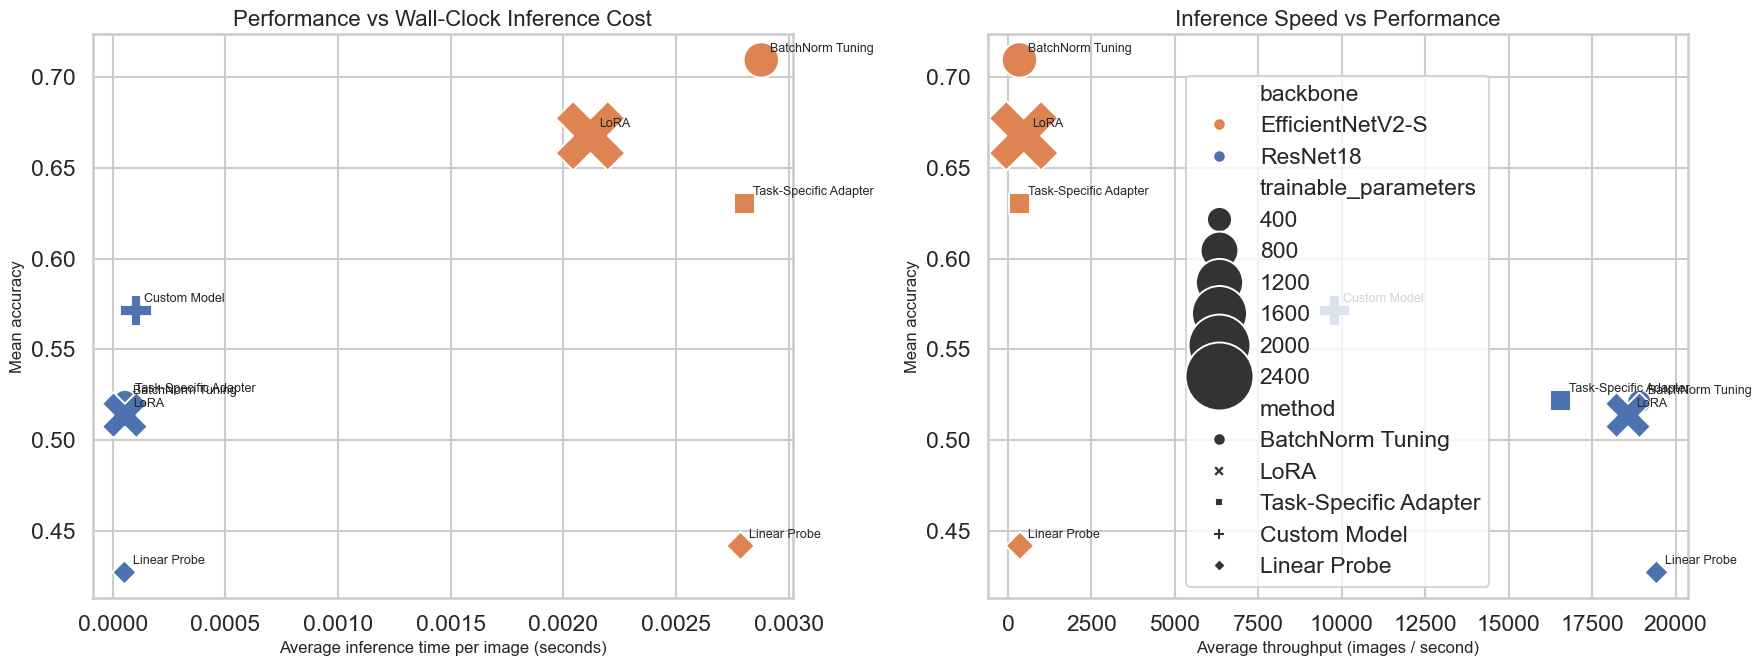

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
size_scale = model_summary["trainable_parameters"] / model_summary["trainable_parameters"].max()
bubble_sizes = 300 + 2200 * size_scale

sns.scatterplot(
    data=model_summary, x="avg_time_per_image", y="mean_accuracy", size=bubble_sizes,
    hue="backbone", style="method", palette=palette, sizes=(300, 2500), legend=False, ax=axes[0]
)
for _, row in model_summary.iterrows():
    axes[0].annotate(row["method"], (row["avg_time_per_image"], row["mean_accuracy"]), xytext=(6, 6), textcoords="offset points", fontsize=9)
axes[0].set_title("Performance vs Wall-Clock Inference Cost")
axes[0].set_xlabel("Average inference time per image (seconds)")
axes[0].set_ylabel("Mean accuracy")

sns.scatterplot(
    data=model_summary, x="avg_throughput", y="mean_accuracy", size=bubble_sizes,
    hue="backbone", style="method", palette=palette, sizes=(300, 2500), legend="brief", ax=axes[1]
)
for _, row in model_summary.iterrows():
    axes[1].annotate(row["method"], (row["avg_throughput"], row["mean_accuracy"]), xytext=(6, 6), textcoords="offset points", fontsize=9)
axes[1].set_title("Inference Speed vs Performance")
axes[1].set_xlabel("Average throughput (images / second)")
axes[1].set_ylabel("Mean accuracy")

plt.tight_layout()
plt.show()
